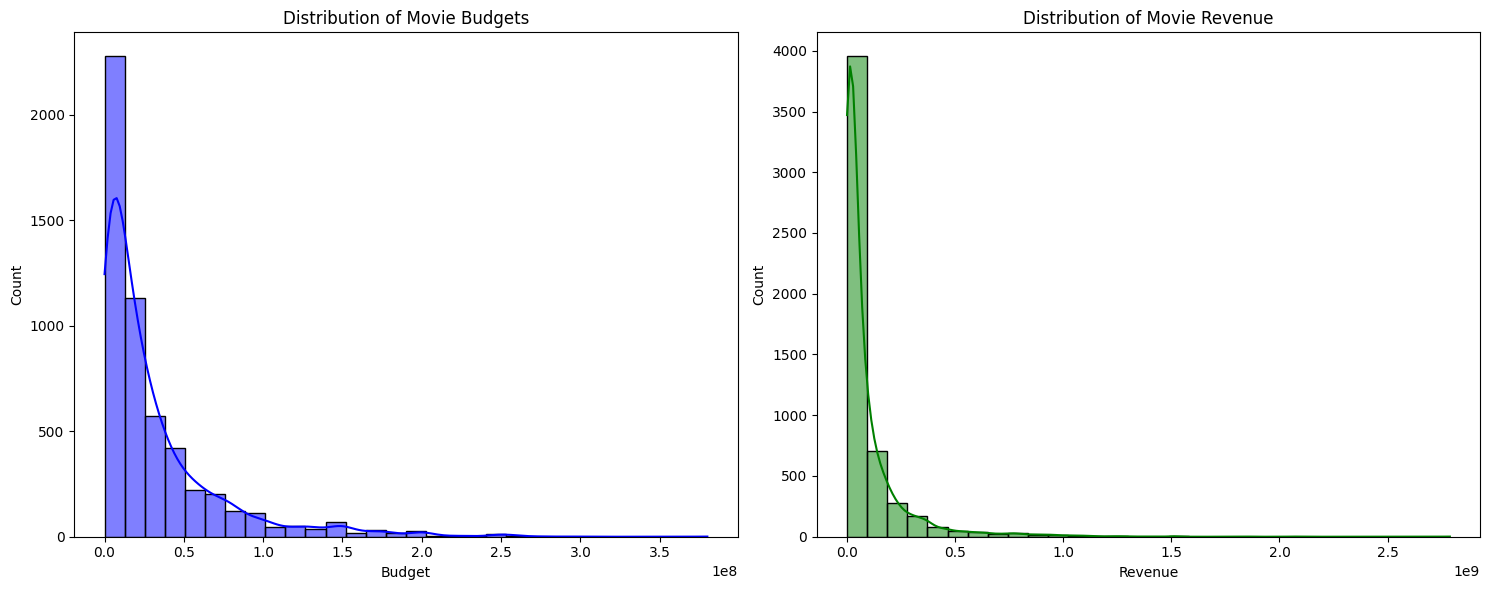

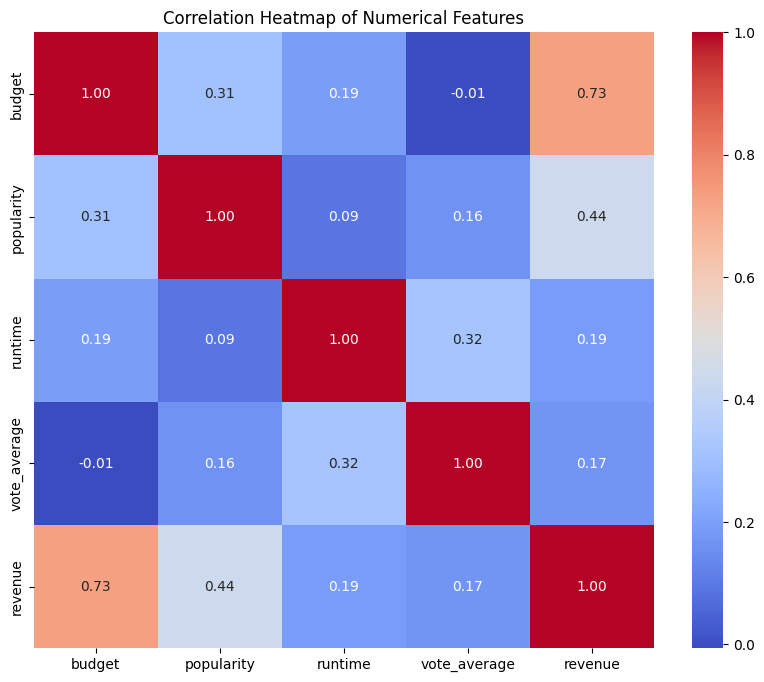

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
file_path = '../data/AI_movies_dataset.csv'
df = pd.read_csv(file_path, low_memory=False)

# Data Cleaning: Convert relevant columns to numeric, coercion will turn non-numeric values to NaN
cols_to_fix = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where budget or revenue are 0 or NaN for meaningful distribution analysis
df_filtered = df[(df['budget'] > 0) & (df['revenue'] > 0)].dropna(subset=cols_to_fix)

# EDA: Distributions of Budget and Revenue
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_filtered['budget'], bins=30, kde=True, color='blue')
plt.title('Distribution of Movie Budgets')
plt.xlabel('Budget')

plt.subplot(1, 2, 2)
sns.histplot(df_filtered['revenue'], bins=30, kde=True, color='green')
plt.title('Distribution of Movie Revenue')
plt.xlabel('Revenue')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_filtered[['budget', 'popularity', 'runtime', 'vote_average', 'revenue']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px

# Selecting features for clustering
features = ['budget', 'popularity', 'vote_average', 'revenue']
X = df_filtered[features]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_filtered['cluster'] = kmeans.fit_predict(X_scaled)

# Apply PCA to reduce to 2 dimensions for the map
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

df_filtered['pca_1'] = pca_results[:, 0]
df_filtered['pca_2'] = pca_results[:, 1]

# Map cluster IDs to descriptive names based on characteristics
cluster_map = {0: 'Niche / Low Budget', 1: 'Blockbusters', 2: 'Popular Hits', 3: 'Cult Classics'}
df_filtered['cluster_label'] = df_filtered['cluster'].map(cluster_map)

# Create the 2D Scatter Plot
fig = px.scatter(
    df_filtered,
    x='pca_1',
    y='pca_2',
    color='cluster_label',
    hover_data=['original_title', 'budget', 'revenue', 'vote_average'],
    title='Movie Discovery Map (PCA + K-Means)',
    labels={'pca_1': 'PCA Component 1', 'pca_2': 'PCA Component 2'}
)

fig.show()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Define the full set of numerical features for clustering
cluster_features = ['budget', 'revenue', 'runtime', 'popularity', 'vote_average']

# Prepare the data (using df_filtered created in previous cells)
X_cluster = df_filtered[cluster_features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Apply K-Means clustering
# We'll use 4 clusters to align with the previous mapping strategy
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_filtered['cluster_id'] = kmeans.fit_predict(X_scaled)

# Analyze the clusters by calculating the mean of each feature
cluster_analysis = df_filtered.groupby('cluster_id')[cluster_features].mean()

# Display the cluster characteristics
print("Cluster Profile (Mean Values):")
print(cluster_analysis)

# Optional: Display counts per cluster
print("\nNumber of movies per cluster:")
print(df_filtered['cluster_id'].value_counts().sort_index())

Cluster Profile (Mean Values):
                  budget       revenue     runtime  popularity  vote_average
cluster_id                                                                  
0           1.320517e+08  4.833128e+08  119.703704   18.451591      6.487500
1           2.117568e+07  6.375804e+07  122.971586    9.244153      6.949267
2           1.317500e+08  8.310870e+08  129.625000  206.561415      7.256250
3           2.252924e+07  4.537935e+07   97.732000    7.690308      5.698618

Number of movies per cluster:
cluster_id
0     432
1    2182
2      16
3    2750
Name: count, dtype: int64


Random Forest Performance:
Mean Squared Error: 7,864,071,593,539,090.00
R-squared Score: 0.6733


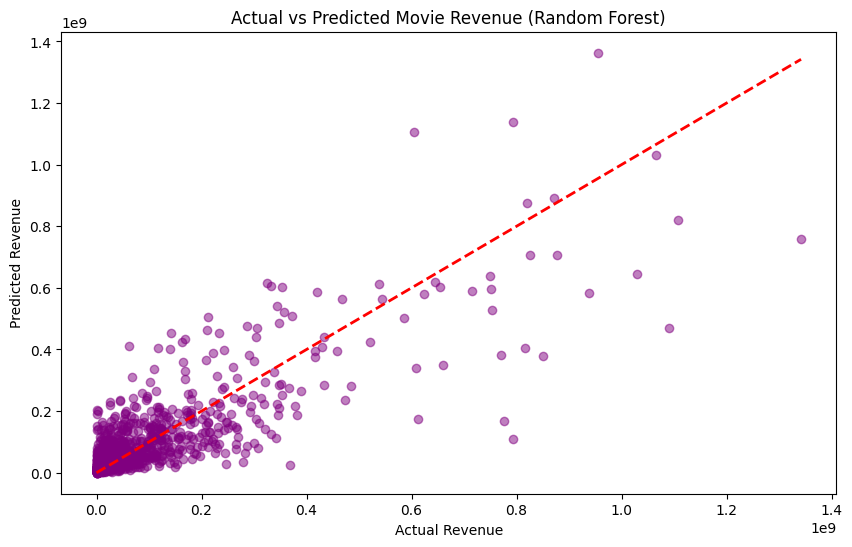


Feature Importances:
        Feature  Importance
0        budget    0.580380
1    popularity    0.237593
3  vote_average    0.097982
2       runtime    0.084046


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Features and Target for predicting revenue
features = ['budget', 'popularity', 'runtime', 'vote_average']
target = 'revenue'

# Prepare data
X = df_filtered[features]
y = df_filtered[target]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Random Forest Performance:')
print(f'Mean Squared Error: {mse:,.2f}')
print(f'R-squared Score: {r2:.4f}')

# Visualize Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Movie Revenue (Random Forest)')
plt.show()

# Feature Importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print('\nFeature Importances:')
print(feature_importance_df)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Create a binary classification target: Is the movie a 'hit' (revenue > budget)?
df_filtered['is_hit'] = (df_filtered['revenue'] > df_filtered['budget']).astype(int)

# Features for classification
features_class = ['budget', 'popularity', 'runtime', 'vote_average']
X_c = df_filtered[features_class]
y_c = df_filtered['is_hit']

# Split the data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

# Standardize features (crucial for SVC and Logistic Regression)
scaler_c = StandardScaler()
X_train_scaled = scaler_c.fit_transform(X_train_c)
X_test_scaled = scaler_c.transform(X_test_c)

# 1. Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_scaled)

# 2. Support Vector Classifier (SVC)
svc_model = SVC(kernel='rbf', random_state=42)
svc_model.fit(X_train_scaled, y_train_c)
y_pred_svc = svc_model.predict(X_test_scaled)

# Evaluation
print('--- Logistic Regression Performance ---')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_log):.4f}')
print(classification_report(y_test_c, y_pred_log))

print('\n--- SVC Performance ---')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_svc):.4f}')
print(classification_report(y_test_c, y_pred_svc))

# Comparison summary
log_acc = accuracy_score(y_test_c, y_pred_log)
svc_acc = accuracy_score(y_test_c, y_pred_svc)
winner = 'Logistic Regression' if log_acc > svc_acc else 'SVC'
print(f'\nResult: {winner} performed better in terms of accuracy.')

--- Logistic Regression Performance ---
Accuracy: 0.7230
              precision    recall  f1-score   support

           0       0.58      0.20      0.30       315
           1       0.74      0.94      0.83       761

    accuracy                           0.72      1076
   macro avg       0.66      0.57      0.56      1076
weighted avg       0.69      0.72      0.67      1076


--- SVC Performance ---
Accuracy: 0.7351
              precision    recall  f1-score   support

           0       0.76      0.14      0.24       315
           1       0.73      0.98      0.84       761

    accuracy                           0.74      1076
   macro avg       0.75      0.56      0.54      1076
weighted avg       0.74      0.74      0.66      1076


Result: SVC performed better in terms of accuracy.
